In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

import xgboost as xgb
from sklearn.model_selection import GridSearchCV

In [1]:


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
import keras_tuner as kt

In [3]:
df = pd.read_csv('Telco-Customer.csv')
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
print((df == " ").sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


TotalCharges  column have missing values need hadle these values 

In [4]:

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

C:\Users\Haritha Kalhara\AppData\Local\Temp\ipykernel_3948\4237058013.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


convrt churn column to binaryand remove the customer id column

In [5]:
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [6]:
df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


Target variable visualization

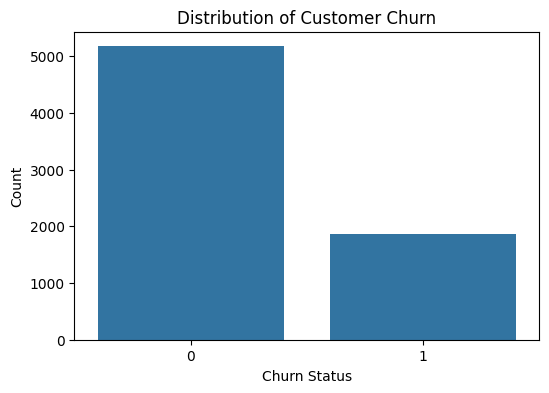

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df)
plt.title("Distribution of Customer Churn")
plt.xlabel("Churn Status")
plt.ylabel("Count")
plt.show()

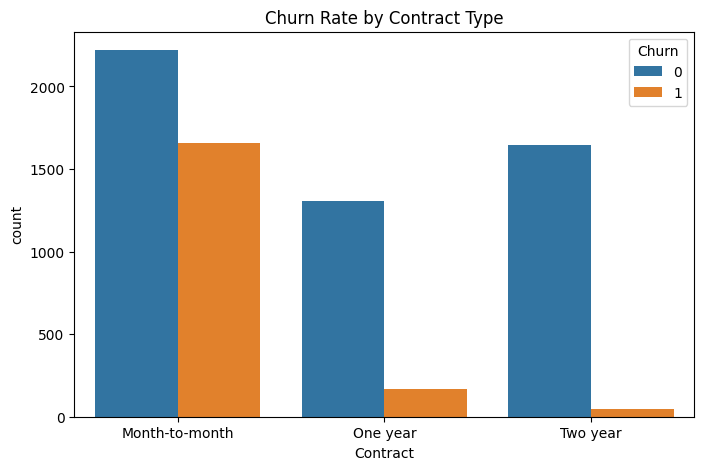

In [8]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Churn Rate by Contract Type")
plt.show()

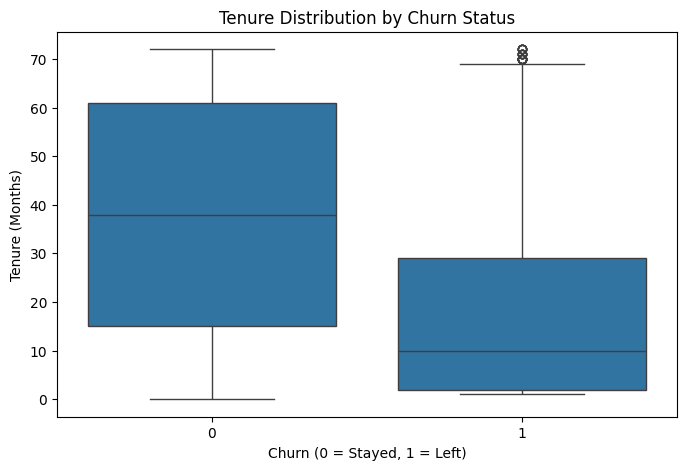

In [9]:

plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure Distribution by Churn Status")
plt.xlabel("Churn (0 = Stayed, 1 = Left)")
plt.ylabel("Tenure (Months)")
plt.show()

clearly shows tenure is high these people stay 

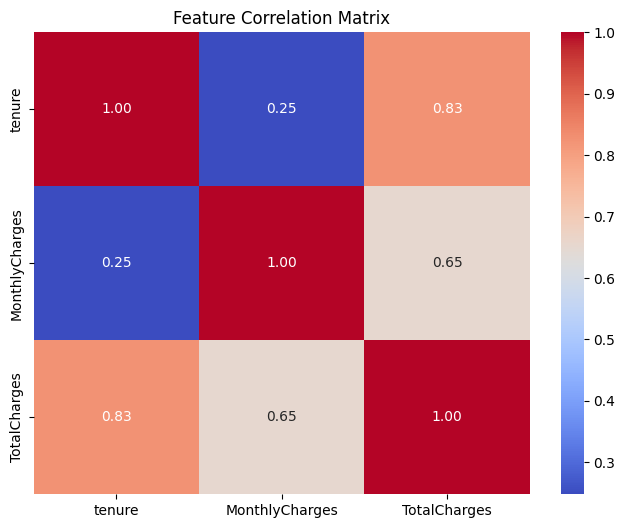

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

this corrplot shows high relationship between tenure and totalCharges

In [ ]:
# Features and Target
X = df.drop('Churn', axis=1)
y = df['Churn']


categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()


print(f"Numerical columns: {numerical_cols}")
print(f"Categorical columns: {categorical_cols}")

if 'SeniorCitizen' in numerical_cols:
    numerical_cols.remove('SeniorCitizen')
    categorical_cols.append('SeniorCitizen')


print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)


Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numerical columns: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'SeniorCitizen']


In [12]:

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ]
)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Training set shape: {X_train_processed.shape}")
print(f"Testing set shape:  {X_test_processed.shape}")

Training set shape: (5634, 30)
Testing set shape:  (1409, 30)


In [ ]:

xgb_clf = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

#  Hyperparameter Grid
param_grid_xgb = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

#  Grid Search CV
grid_xgb = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid_xgb,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train_processed, y_train)

best_xgb = grid_xgb.best_estimator_
print("\n--- XGBoost Best Hyperparameters ---")
print(grid_xgb.best_params_)

# 4. Predictions & Probabilities
y_pred_xgb = best_xgb.predict(X_test_processed)
y_proba_xgb = best_xgb.predict_proba(X_test_processed)[:, 1]

Fitting 5 folds for each of 72 candidates, totalling 360 fits

--- XGBoost Best Hyperparameters ---
{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


In [ ]:
def build_mlp_model(hp):
    model = keras.Sequential()

    # input layer
    model.add(layers.Dense(
        units=hp.Int('units_1', min_value=32, max_value=128, step=32),
        activation='relu',
        input_shape=(X_train_processed.shape[1],)
    ))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(hp.Float('dropout_1', min_value=0.1, max_value=0.4, step=0.1)))

    #  Hidden Layer
    model.add(layers.Dense(
        units=hp.Int('units_2', min_value=16, max_value=64, step=16),
        activation='relu'
    ))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(hp.Float('dropout_2', min_value=0.1, max_value=0.4, step=0.1)))

    # Output Layer
    model.add(layers.Dense(1, activation='sigmoid'))

    
    lr = hp.Choice('learning_rate', values=[1e-2, 1e-3, 5e-4])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model


tuner = kt.RandomSearch(
    build_mlp_model,
    objective='val_auc',
    max_trials=8,
    executions_per_trial=1,
    directory='mlp_hpo_dir',
    project_name='telco_mlp',
    overwrite=True
)


early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Best Hyperparameters
tuner.search(
    X_train_processed, y_train,
    epochs=50,
    validation_split=0.2,
    callbacks=[early_stop],
    batch_size=64,
    verbose=1
)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\n--- Keras MLP Best Hyperparameters ---")
print(f"Units Layer 1: {best_hps.get('units_1')}")
print(f"Units Layer 2: {best_hps.get('units_2')}")
print(f"Dropout Layer 1: {best_hps.get('dropout_1')}")
print(f"Dropout Layer 2: {best_hps.get('dropout_2')}")
print(f"Learning Rate: {best_hps.get('learning_rate')}")

# Final Keras MLP Model 
best_mlp = tuner.hypermodel.build(best_hps)
history = best_mlp.fit(
    X_train_processed, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

#  Predictions
y_proba_mlp = best_mlp.predict(X_test_processed).ravel()
y_pred_mlp = (y_proba_mlp >= 0.5).astype(int)

Trial 8 Complete [00h 00m 10s]
val_auc: 0.8272368311882019

Best val_auc So Far: 0.8285242319107056
Total elapsed time: 00h 01m 48s

--- Keras MLP Best Hyperparameters ---
Units Layer 1: 96
Units Layer 2: 16
Dropout Layer 1: 0.1
Dropout Layer 2: 0.30000000000000004
Learning Rate: 0.01
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [18]:
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score, 
    confusion_matrix, 
    roc_curve
)

In [ ]:
def compute_metrics(y_true, y_pred, y_proba):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba)
    }

xgb_metrics = compute_metrics(y_test, y_pred_xgb, y_proba_xgb)
mlp_metrics = compute_metrics(y_test, y_pred_mlp, y_proba_mlp)

# Comparison Table
results_df = pd.DataFrame([xgb_metrics, mlp_metrics], index=['XGBoost Classifier', 'Keras MLP'])
print("\n=================== MODEL PERFORMANCE COMPARISON ===================")
print(results_df.round(4))
print("====================================================================")




=================== MODEL PERFORMANCE COMPARISON ===================
                    Accuracy  Precision  Recall  F1-Score  ROC-AUC
XGBoost Classifier     0.802     0.6589  0.5267    0.5854   0.8459
Keras MLP              0.797     0.6705  0.4626    0.5475   0.8411


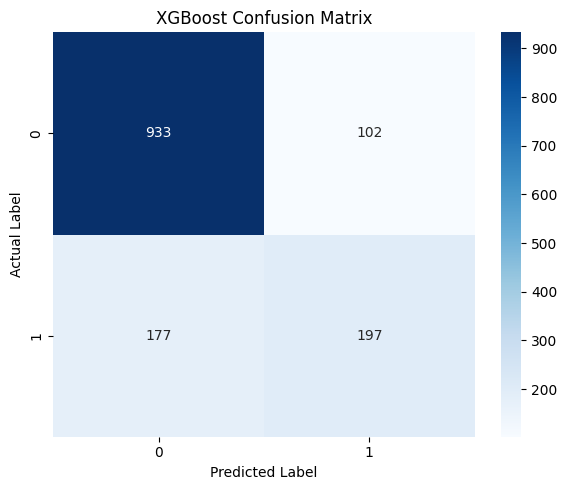

In [22]:
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Blues')
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

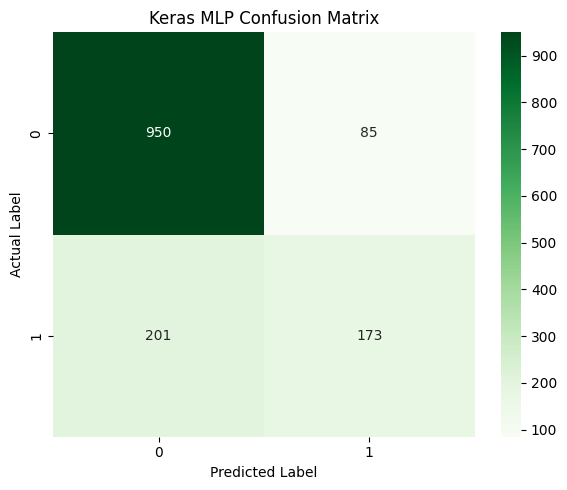

In [21]:
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_mlp), annot=True, fmt='d', cmap='Greens')
plt.title('Keras MLP Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

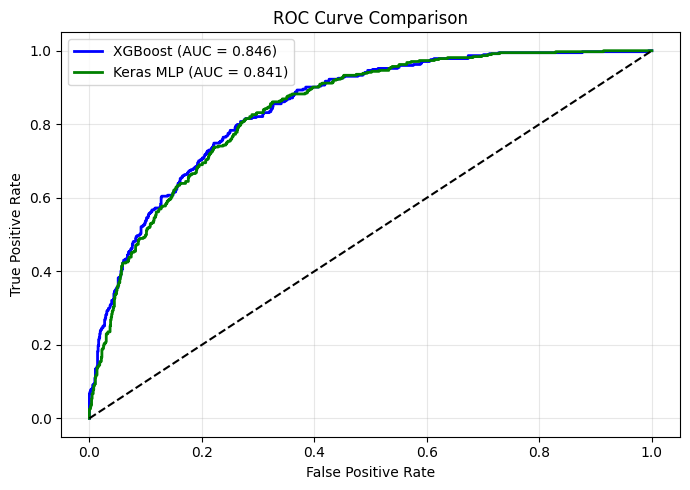

In [23]:
plt.figure(figsize=(7, 5))
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_proba_mlp)

plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {xgb_metrics['ROC-AUC']:.3f})", color='blue', lw=2)
plt.plot(fpr_mlp, tpr_mlp, label=f"Keras MLP (AUC = {mlp_metrics['ROC-AUC']:.3f})", color='green', lw=2)
plt.plot([0, 1], [0, 1], 'k--', lw=1.5)

plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Best Model Selection 
best_model_name = "XGBoost" if xgb_metrics['ROC-AUC'] > mlp_metrics['ROC-AUC'] else "Keras MLP"
print(f"\n Conclusion: Based on ROC-AUC score, the {best_model_name} model performed best for this dataset.")


 Conclusion: Based on ROC-AUC score, the XGBoost model performed best for this dataset.
